# 01. Los datos del proyecto, explicados

**Para quién es este notebook:** cualquier persona, sin necesidad de saber de computación cuántica. Cada gráfica lleva sus ejes explicados y una conclusión en una frase.

**Qué vas a ver, en orden:**
1. **Qué aspecto tiene un circuito cuántico** (el "programa" que ejecuta la máquina) y cómo lo convertimos en algo que una red neuronal puede leer
2. **El "parte médico" de la máquina** — las propiedades físicas de cada qubit del chip
3. **Cómo se degrada la máquina con el tiempo** — el fenómeno que nuestro modelo debe aprender a compensar
4. **El dataset de entrenamiento** — qué contiene y qué pinta tienen los datos

El contexto general del proyecto está en [`GUIA_TUTOR.md`](../GUIA_TUTOR.md). Este es el pipeline (este notebook analiza los datos que alimentan al modelo GEM y a sus baselines):

![Pipeline del TFM](../figures/pipeline_tfm.png)

> ✅ **Los datos de este notebook son REALES**: la calibración se descargó de `ibm_kingston` (IBM) el 14-jul-2026, y existe un histórico diario de calibraciones reales en `data/raw/calib_history/` que crece cada día.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import BACKEND_NAME, LABEL_SHOTS, PROCESSED_DATA_PATH, RAW_DATA_PATH, SEED, set_global_seeds

set_global_seeds()

# Paleta categórica validada (CVD-safe, orden fijo) + tinta
C = {"blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100",
     "green": "#008300", "violet": "#4a3aa7", "red": "#e34948"}
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.axisbelow": True, "font.size": 9.5,
})

print(f"Backend: {BACKEND_NAME} | Seed: {SEED} | Shots para etiquetas: {LABEL_SHOTS}")

Backend: ibm_kingston | Seed: 42 | Shots para etiquetas: 4096


## 1. ¿Qué aspecto tiene un circuito cuántico?

Un circuito cuántico es el "programa" que ejecuta la máquina. Se lee **de izquierda a derecha**:

- Cada **línea horizontal** es un qubit (la unidad de información cuántica)
- Cada **símbolo sobre una línea** es una *puerta*: una operación sobre ese qubit
- Los **símbolos que conectan dos líneas** son puertas de dos qubits — las que crean el "entrelazamiento" (y las que más error introducen: ~10 veces más que las de un solo qubit)

Generamos uno pequeño de ejemplo con el mismo generador que produce el dataset:

Cargando calibración offline desde /home/grego/TFM/TFM-Quantum/data/raw/ibm_kingston_calib.json...
Circuito de ejemplo (HEA, 4 qubits) tras adaptarlo al chip Heron:
  · 37 puertas en total: {'sx': 18, 'rz': 16, 'cz': 3}
  · 'cz' son las puertas de 2 qubits (las más propensas a error)



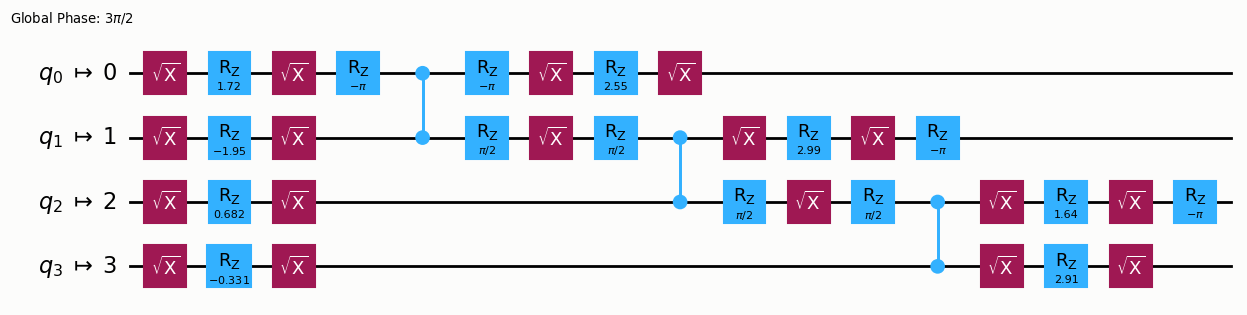

In [2]:
from src.quantum_gen import CircuitFactory, HardwareTelemetrics, QuantumGraphExtractor

hw = HardwareTelemetrics()
factory = CircuitFactory(min_qubits=3, max_qubits=5)
qc_demo = factory.generate_hea(num_qubits=4, seed=SEED, reps=1, coupling_map=hw.coupling_map)

print(f"Circuito de ejemplo (HEA, 4 qubits) tras adaptarlo al chip Heron:")
print(f"  · {sum(qc_demo.count_ops().values())} puertas en total: {dict(qc_demo.count_ops())}")
print(f"  · 'cz' son las puertas de 2 qubits (las más propensas a error)\n")
qc_demo.draw("mpl", fold=28, style={"backgroundcolor": "#fcfcfb"})

### De circuito a grafo: lo que "ve" la red neuronal

Una red neuronal no entiende el dibujo de arriba. Lo traducimos a un **grafo**: cada puerta se convierte en un **nodo** (un punto), y se dibuja una **flecha** entre dos puertas cuando una debe ejecutarse antes que la otra sobre el mismo qubit.

Cada nodo lleva además una "ficha" de 19 números que describe: qué tipo de puerta es, sus parámetros, la salud de los qubits sobre los que actúa ese día (del parte médico), y su posición en el circuito. **Ese grafo con fichas es exactamente el input del modelo GEM.**

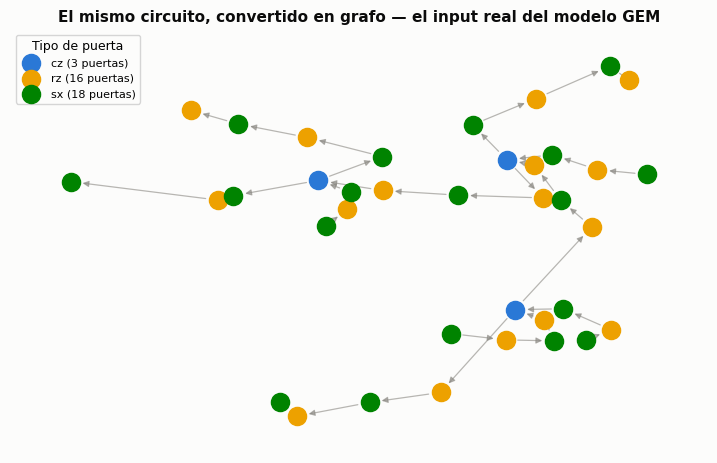

Grafo: 37 nodos (puertas) × 19 características cada uno, 36 flechas (dependencias)


In [3]:
extractor = QuantumGraphExtractor(hw)
data_demo = extractor.circuit_to_graph(qc_demo, delta=0.0, day_index=0)

gate_names = ["cz", "id", "rz", "sx", "x", "measure"]
gate_colors = [C["blue"], C["aqua"], C["yellow"], C["green"], C["violet"], C["red"]]
node_gate = data_demo.x[:, :6].argmax(dim=1).numpy()

G = nx.DiGraph()
G.add_nodes_from(range(data_demo.x.shape[0]))
G.add_edges_from(data_demo.edge_index.t().tolist())
pos = nx.spring_layout(G, seed=SEED)

fig, ax = plt.subplots(figsize=(9, 5.5))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=MUTED, arrows=True, arrowsize=9, width=0.9, alpha=0.6)
for gid, (name, color) in enumerate(zip(gate_names, gate_colors)):
    nodes = [n for n in G.nodes if node_gate[n] == gid]
    if nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color, node_size=170,
                               label=f"{name} ({len(nodes)} puertas)", ax=ax)
ax.legend(title="Tipo de puerta", loc="upper left", fontsize=8, title_fontsize=9)
ax.set_title("El mismo circuito, convertido en grafo — el input real del modelo GEM")
ax.grid(False); ax.axis("off")
plt.show()
print(f"Grafo: {data_demo.x.shape[0]} nodos (puertas) × 19 características cada uno, {data_demo.edge_index.shape[1]} flechas (dependencias)")

## 2. El "parte médico" de la máquina (calibración)

IBM publica a diario las propiedades físicas de cada qubit de sus chips. Son la materia prima de las "fichas" de los nodos. Las cinco magnitudes:

| Magnitud | Qué mide, en llano | Bueno es... |
|---|---|---|
| **T1** | Cuánto tiempo "recuerda" el qubit su estado antes de degradarse | Alto (más microsegundos) |
| **T2** | Cuánto tiempo mantiene la "superposición" (su propiedad cuántica clave) | Alto |
| **readout_error** | Con qué frecuencia el sensor lee el estado equivocado | Bajo (%) |
| **gate_error** | Con qué frecuencia falla una operación individual | Bajo |
| **gate_length** | Cuánto dura físicamente cada operación | Bajo (nanosegundos) |

In [4]:
calib_path = Path(RAW_DATA_PATH) / f"{BACKEND_NAME}_calib.json"
with open(calib_path) as f:
    calib = json.load(f)

df_calib = pd.DataFrame(calib["properties"]).T.astype(float)
df_calib.index = df_calib.index.astype(int)
df_calib = df_calib.sort_index()

print(f"Fichero: {calib_path.name} | ¿Sintética?: {calib.get('_synthetic', False)} | Qubits: {len(df_calib)}")
resumen = df_calib.describe().loc[["mean", "min", "max"]].T
resumen["en unidades legibles"] = [
    f"{df_calib['T1'].mean()*1e6:.0f} µs de media",
    f"{df_calib['T2'].mean()*1e6:.0f} µs de media",
    f"{df_calib['readout_error'].mean()*100:.1f}% de media",
    f"{df_calib['gate_error'].mean()*1e4:.1f}×10⁻⁴ de media",
    f"{df_calib['gate_length'].mean()*1e9:.0f} ns de media",
]
resumen

Fichero: ibm_kingston_calib.json | ¿Sintética?: False | Qubits: 156


,mean,min,max,en unidades legibles
T1,2.359372e-04,2.821809e-06,4.222142e-04,236 µs de media
T2,1.618002e-04,1.216349e-05,6.363268e-04,162 µs de media
readout_error,1.919759e-02,1.464844e-03,3.247070e-01,1.9% de media
gate_error,1.989650e-02,8.795186e-05,1.000000e+00,199.0×10⁻⁴ de media
gate_length,3.201923e-08,3.200000e-08,3.500000e-08,32 ns de media


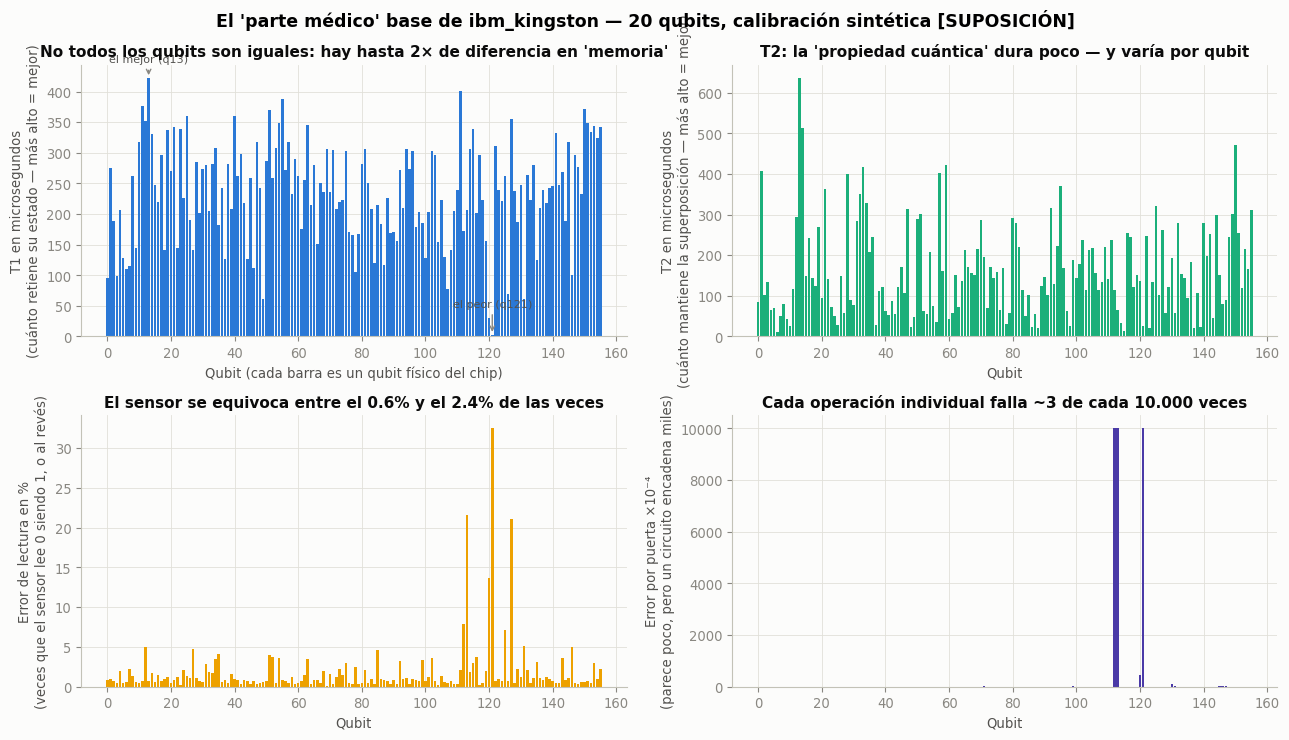

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))

t1_us = df_calib["T1"] * 1e6
best, worst = t1_us.idxmax(), t1_us.idxmin()

axes[0, 0].bar(df_calib.index, t1_us, color=C["blue"])
axes[0, 0].set_title("No todos los qubits son iguales: hay hasta 2× de diferencia en 'memoria'")
axes[0, 0].set_xlabel("Qubit (cada barra es un qubit físico del chip)")
axes[0, 0].set_ylabel("T1 en microsegundos\n(cuánto retiene su estado — más alto = mejor)")
axes[0, 0].annotate(f"el mejor (q{best})", xy=(best, t1_us[best]), xytext=(best, t1_us[best] + 25),
                    ha="center", fontsize=8, color=INK2, arrowprops=dict(arrowstyle="->", color=MUTED))
axes[0, 0].annotate(f"el peor (q{worst})", xy=(worst, t1_us[worst]), xytext=(worst, t1_us[worst] + 45),
                    ha="center", fontsize=8, color=INK2, arrowprops=dict(arrowstyle="->", color=MUTED))

axes[0, 1].bar(df_calib.index, df_calib["T2"] * 1e6, color=C["aqua"])
axes[0, 1].set_title("T2: la 'propiedad cuántica' dura poco — y varía por qubit")
axes[0, 1].set_xlabel("Qubit")
axes[0, 1].set_ylabel("T2 en microsegundos\n(cuánto mantiene la superposición — más alto = mejor)")

axes[1, 0].bar(df_calib.index, df_calib["readout_error"] * 100, color=C["yellow"])
axes[1, 0].set_title("El sensor se equivoca entre el 0.6% y el 2.4% de las veces")
axes[1, 0].set_xlabel("Qubit")
axes[1, 0].set_ylabel("Error de lectura en %\n(veces que el sensor lee 0 siendo 1, o al revés)")

axes[1, 1].bar(df_calib.index, df_calib["gate_error"] * 1e4, color=C["violet"])
axes[1, 1].set_title("Cada operación individual falla ~3 de cada 10.000 veces")
axes[1, 1].set_xlabel("Qubit")
axes[1, 1].set_ylabel("Error por puerta ×10⁻⁴\n(parece poco, pero un circuito encadena miles)")

fig.suptitle(f"El 'parte médico' base de {BACKEND_NAME} — 20 qubits, calibración sintética [SUPOSICIÓN]",
             fontweight="bold", fontsize=12.5)
fig.tight_layout()
plt.show()

📌 **En una frase:** los qubits de un mismo chip son *desiguales* — por eso el modelo recibe la salud de cada qubit concreto que usa cada puerta, y no una media global.

*(Detalle de la última gráfica: un error de 3 de cada 10.000 parece despreciable, pero un circuito de nuestro dataset encadena ~1.300 puertas — el error se acumula multiplicativamente y ahí está el problema que mitigamos.)*

## 3. La máquina de hoy no es la de ayer (Concept Drift)

Las propiedades de arriba **no son constantes**: cambian con el tiempo, y no suavemente, sino **a saltos bruscos** que persisten (evidencia empírica: Hirasaki et al., *Applied Physics Letters* 2023; impacto operacional: Huo et al., *SIGMETRICS* 2026).

Nuestro simulador reproduce ese comportamiento: cada qubit sufre 2–3 saltos aleatorios de ±15–30% repartidos en una ventana de 10 días. Esto es lo que el modelo debe aprender a compensar, y por eso el día es una de las 19 características de cada nodo.

**La prueba de fuego del proyecto**: el modelo se entrena con los días 1–5 y se examina con los días 8–10, que **nunca vio** — igual que en producción tendría que funcionar mañana habiéndose entrenado con datos de la semana pasada.

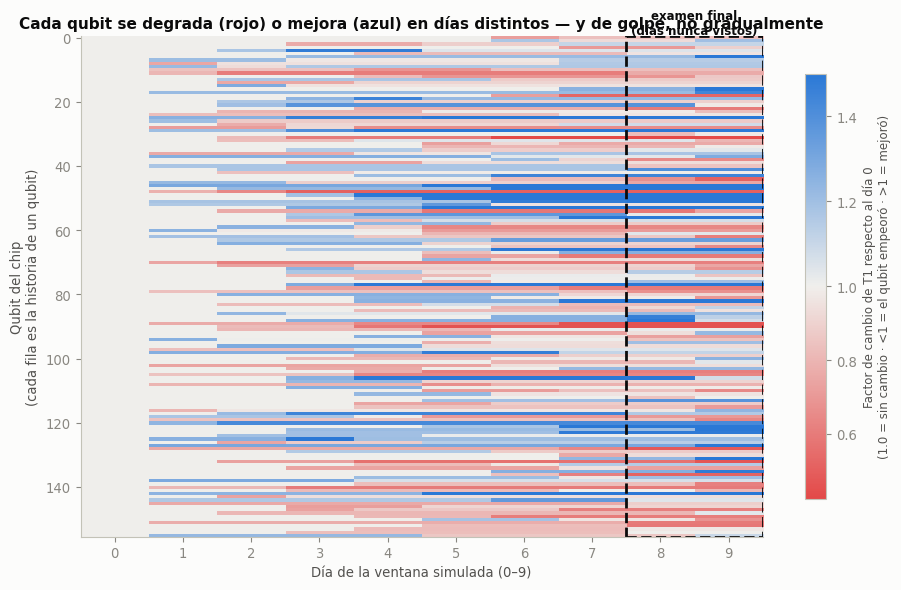

In [6]:
n_q, days = len(df_calib), list(range(10))
factor = np.array([[hw.get_qubit_features(q, d)["T1"] / df_calib["T1"][q] for d in days] for q in range(n_q)])

# Divergente azul↔rojo con punto neutro gris en 1.0 (= sin cambio)
cmap = mcolors.LinearSegmentedColormap.from_list("drift", [C["red"], "#f0efec", C["blue"]])
norm = mcolors.TwoSlopeNorm(vmin=factor.min(), vcenter=1.0, vmax=factor.max())

fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(factor, aspect="auto", cmap=cmap, norm=norm)
ax.set_title("Cada qubit se degrada (rojo) o mejora (azul) en días distintos — y de golpe, no gradualmente")
ax.set_xlabel("Día de la ventana simulada (0–9)")
ax.set_ylabel("Qubit del chip\n(cada fila es la historia de un qubit)")
ax.set_xticks(days); ax.grid(False)
ax.axvspan(7.5, 9.5, fill=False, edgecolor=INK, linewidth=2, linestyle="--")
ax.text(8.5, -1.1, "examen final\n(días nunca vistos)", ha="center", fontsize=8.5, color=INK, fontweight="bold")
cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("Factor de cambio de T1 respecto al día 0\n(1.0 = sin cambio · <1 = el qubit empeoró · >1 = mejoró)", fontsize=8.5)
plt.show()

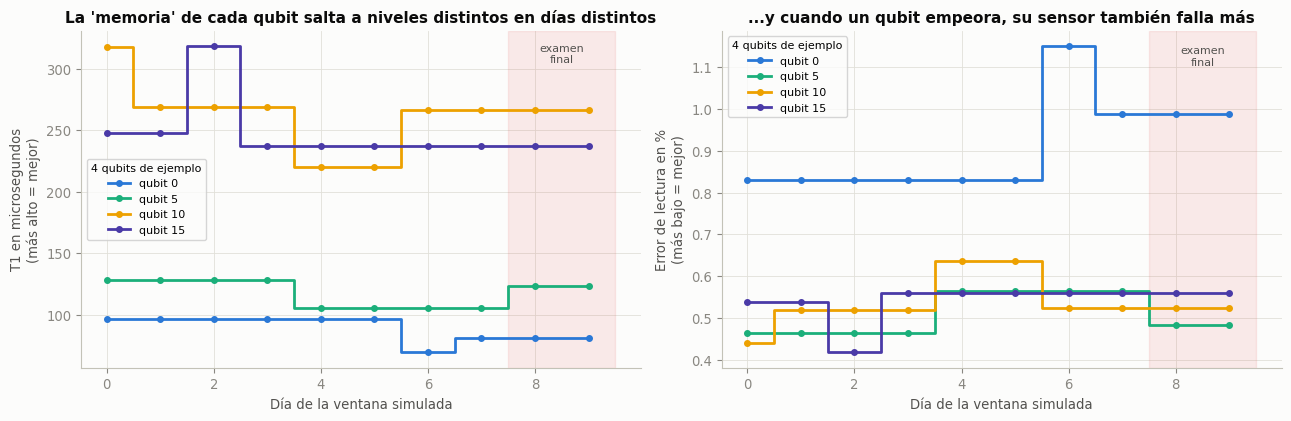

In [7]:
qubits_to_plot = [0, 5, 10, 15]
colors_q = [C["blue"], C["aqua"], C["yellow"], C["violet"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for q, col in zip(qubits_to_plot, colors_q):
    t1 = [hw.get_qubit_features(q, d)["T1"] * 1e6 for d in days]
    ro = [hw.get_qubit_features(q, d)["readout_error"] * 100 for d in days]
    axes[0].step(days, t1, where="mid", marker="o", markersize=4, lw=2, label=f"qubit {q}", color=col)
    axes[1].step(days, ro, where="mid", marker="o", markersize=4, lw=2, label=f"qubit {q}", color=col)

axes[0].set_title("La 'memoria' de cada qubit salta a niveles distintos en días distintos")
axes[0].set_ylabel("T1 en microsegundos\n(más alto = mejor)")
axes[1].set_title("...y cuando un qubit empeora, su sensor también falla más")
axes[1].set_ylabel("Error de lectura en %\n(más bajo = mejor)")
for ax in axes:
    ax.set_xlabel("Día de la ventana simulada")
    ax.axvspan(7.5, 9.5, alpha=0.10, color=C["red"])
    ax.text(8.5, ax.get_ylim()[1] * 0.97, "examen\nfinal", ha="center", va="top", fontsize=8, color=INK2)
    ax.legend(fontsize=8, title="4 qubits de ejemplo", title_fontsize=8)
fig.tight_layout()
plt.show()

📌 **En una frase:** el drift es escalonado, distinto para cada qubit y determinista en nuestra simulación (semilla fija) — el "examen final" (zona marcada) usa configuraciones de la máquina que el modelo jamás vio al entrenar.

## 4. El dataset de entrenamiento

Cada **muestra** del dataset es un circuito completo, guardado ya como grafo, con esta información:

| Campo | Qué contiene, en llano |
|---|---|
| `x` | La "ficha" de 19 números de cada puerta del circuito |
| `edge_index` | Las flechas del grafo (qué puerta va antes de cuál) |
| `y` (**el objetivo**) | **Δ: cuánto se equivocó la máquina** — la diferencia entre el resultado perfecto (calculado matemáticamente) y el resultado con ruido (simulado). Es lo que el Modelo 1 debe aprender a predecir |
| `ideal_probs` | La distribución de resultados perfecta |
| `noisy_probs` | La distribución con ruido, tal y como saldría de la máquina (para análisis) |

Y hay **cinco cajones** de muestras, con una regla de oro: los tipos de circuito QAOA y QFT **jamás aparecen en entrenamiento** — son los exámenes sorpresa para demostrar que el modelo aprende física, no memoriza patrones.

In [8]:
SPLIT_INFO = {
    "train": ("Entrenamiento", "random + HEA + TFIM"),
    "val": ("Validación (ajuste)", "random + HEA + TFIM"),
    "test": ("Test", "random + HEA + TFIM"),
    "zeroshot_qaoa": ("Examen sorpresa A", "QAOA — jamás visto al entrenar"),
    "zeroshot_qft": ("Examen sorpresa B", "QFT — jamás visto al entrenar"),
}
rows = []
for s, (rol, tipos) in SPLIT_INFO.items():
    files = sorted((Path(PROCESSED_DATA_PATH) / s).glob("*.pt"))
    dias = sorted({f.stem.split("_day")[1].split("_")[0] for f in files})
    rows.append({"cajón": s, "rol": rol, "tipos de circuito": tipos,
                 "muestras": len(files), "días": ", ".join(dias)})
df_splits = pd.DataFrame(rows)
print(f"Total: {df_splits['muestras'].sum()} muestras (mini-dataset de validación del pipeline)")
df_splits

Total: 178 muestras (mini-dataset de validación del pipeline)


,cajón,rol,tipos de circuito,muestras,días
0,train,Entrenamiento,random + HEA + TFIM,104,"1, 2"
1,val,Validación (ajuste),random + HEA + TFIM,22,"1, 2"
2,test,Test,random + HEA + TFIM,22,"1, 2"
3,zeroshot_qaoa,Examen sorpresa A,QAOA — jamás visto al entrenar,15,1
4,zeroshot_qft,Examen sorpresa B,QFT — jamás visto al entrenar,15,1


In [9]:
sample_path = sorted((Path(PROCESSED_DATA_PATH) / "train").glob("*.pt"))[0]
sample = torch.load(sample_path, weights_only=False)

print("Una muestra cualquiera, por dentro:")
print(f"  Fichero : {sample_path.name}")
print(f"  Objeto  : {sample}")
print(f"  Δ (el objetivo a predecir): {sample.y.item():+.5f}")
print(f"  Qubits del circuito       : {int(np.log2(sample.ideal_probs.shape[0]))}")
print(f"  Comprobación de sanidad   : ideal_probs suma {sample.ideal_probs.sum():.6f} y noisy_probs suma {sample.noisy_probs.sum():.6f} (ambas deben ser 1.0)")

Una muestra cualquiera, por dentro:
  Fichero : train_day1_sample0.pt
  Objeto  : Data(x=[258, 19], edge_index=[2, 271], y=[1], ideal_probs=[32768], noisy_probs=[32768])
  Δ (el objetivo a predecir): +0.00092
  Qubits del circuito       : 15
  Comprobación de sanidad   : ideal_probs suma 1.000000 y noisy_probs suma 1.000000 (ambas deben ser 1.0)


In [10]:
records = []
for s in SPLIT_INFO:
    for f in sorted((Path(PROCESSED_DATA_PATH) / s).glob("*.pt")):
        d = torch.load(f, weights_only=False)
        records.append({
            "split": s,
            "delta": d.y.item(),
            "n_gates": d.x.shape[0],
            "n_qubits": int(np.log2(d.ideal_probs.shape[0])),
            "n_cz": int((d.x[:, :6].argmax(dim=1) == 0).sum()),
        })
df = pd.DataFrame(records)
df.groupby("split")[["delta", "n_gates", "n_qubits", "n_cz"]].agg(["mean", "std", "min", "max"]).round(4)

delta                            n_gates                  \
                 mean     std     min     max       mean        std  min   
split                                                                      
test           0.0003  0.0108 -0.0207  0.0207  1428.3636  1271.0303   72   
train          0.0016  0.0111 -0.0217  0.0465  1516.7019  1317.3943   69   
val           -0.0010  0.0124 -0.0190  0.0418  1656.0909  1970.0879  114   
zeroshot_qaoa -0.0008  0.0042 -0.0073  0.0061   220.8667    97.1404  110   
zeroshot_qft  -0.0006  0.0027 -0.0067  0.0036  1700.0667   736.7250  234   

                    n_qubits                      n_cz                      
                max     mean     std min max      mean       std min   max  
split                                                                       
test           3935   9.8636  2.8502   5  14  331.9545  325.2873   5   974  
train          5210  10.1827  3.1462   5  15  354.7596  340.5686   2  1333  
val            7878   9.7727  3.6636   5  15  395.2727  531.1632  12  2098  
zeroshot_qaoa   401   9.4000  2.6403   5  15   30.5333   14.3122  14    56  
zeroshot_qft   2806  11.4667  2.6957   5  15  396.8000  174.2454  50   654

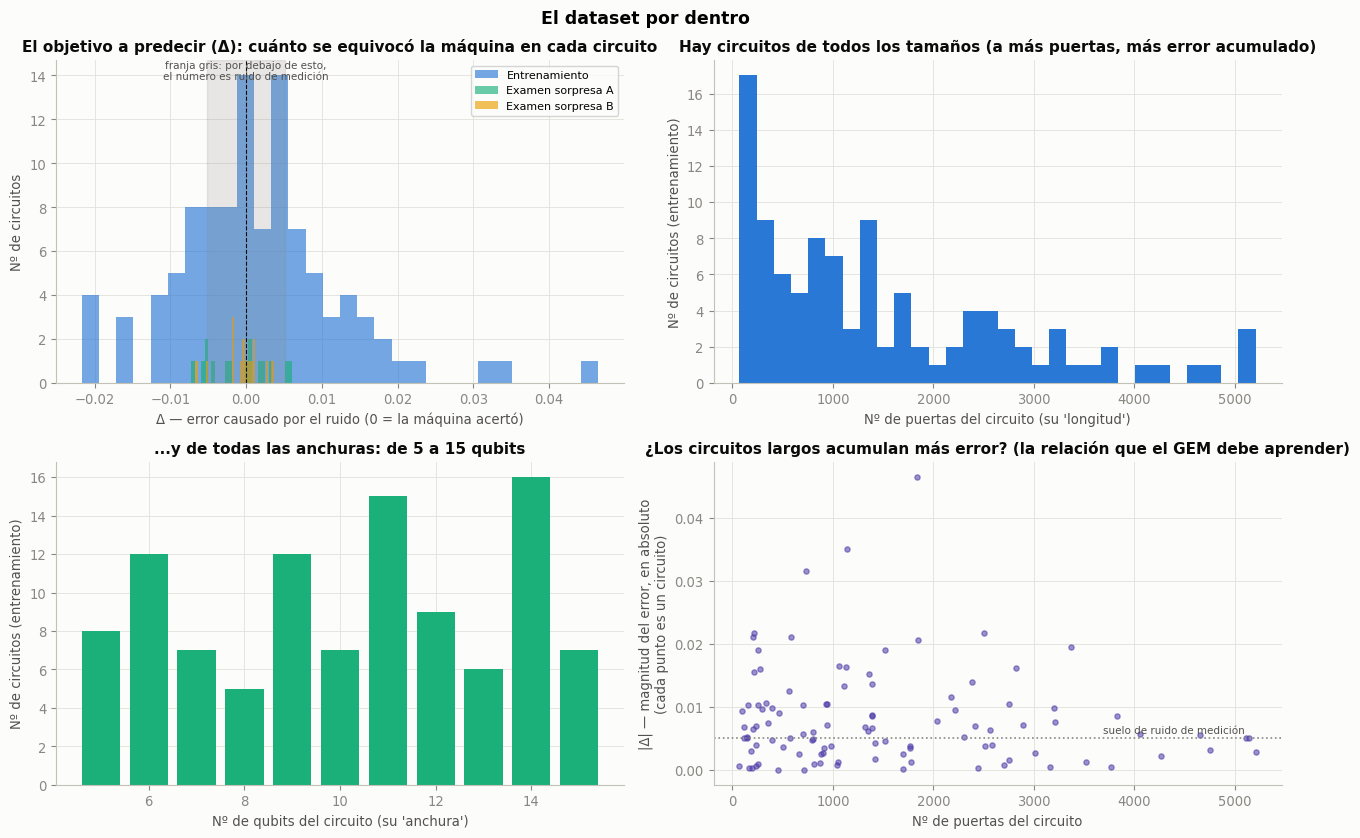

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

# --- Δ por split, con la franja de ruido de medición ---
shot_floor = float(np.mean([np.sqrt(1.0 / (n * LABEL_SHOTS)) for n in df.n_qubits]))
for s, col in zip(["train", "zeroshot_qaoa", "zeroshot_qft"], [C["blue"], C["aqua"], C["yellow"]]):
    axes[0, 0].hist(df[df.split == s].delta, bins=30, alpha=0.65, label=SPLIT_INFO[s][0], color=col)
axes[0, 0].axvspan(-shot_floor, shot_floor, color=MUTED, alpha=0.18)
axes[0, 0].axvline(0, color=INK, lw=0.8, ls="--")
axes[0, 0].text(0, axes[0, 0].get_ylim()[1] * 0.94, "franja gris: por debajo de esto,\nel número es ruido de medición",
                ha="center", fontsize=7.5, color=INK2)
axes[0, 0].set_title("El objetivo a predecir (Δ): cuánto se equivocó la máquina en cada circuito")
axes[0, 0].set_xlabel("Δ — error causado por el ruido (0 = la máquina acertó)")
axes[0, 0].set_ylabel("Nº de circuitos")
axes[0, 0].legend(fontsize=8)

# --- Tamaño de circuitos ---
axes[0, 1].hist(df[df.split == "train"].n_gates, bins=30, color=C["blue"])
axes[0, 1].set_title("Hay circuitos de todos los tamaños (a más puertas, más error acumulado)")
axes[0, 1].set_xlabel("Nº de puertas del circuito (su 'longitud')")
axes[0, 1].set_ylabel("Nº de circuitos (entrenamiento)")

# --- Qubits ---
qc_counts = df[df.split == "train"].n_qubits.value_counts().sort_index()
axes[1, 0].bar(qc_counts.index, qc_counts.values, color=C["aqua"])
axes[1, 0].set_title("...y de todas las anchuras: de 5 a 15 qubits")
axes[1, 0].set_xlabel("Nº de qubits del circuito (su 'anchura')")
axes[1, 0].set_ylabel("Nº de circuitos (entrenamiento)")

# --- Δ vs tamaño ---
tr = df[df.split == "train"]
axes[1, 1].scatter(tr.n_gates, tr.delta.abs(), s=14, alpha=0.55, color=C["violet"])
axes[1, 1].axhline(shot_floor, color=MUTED, lw=1.2, ls=":")
axes[1, 1].text(tr.n_gates.max() * 0.98, shot_floor * 1.15, "suelo de ruido de medición",
                ha="right", fontsize=7.5, color=INK2)
axes[1, 1].set_title("¿Los circuitos largos acumulan más error? (la relación que el GEM debe aprender)")
axes[1, 1].set_xlabel("Nº de puertas del circuito")
axes[1, 1].set_ylabel("|Δ| — magnitud del error, en absoluto\n(cada punto es un circuito)")

fig.suptitle("El dataset por dentro", fontweight="bold", fontsize=12.5)
fig.tight_layout()
plt.show()

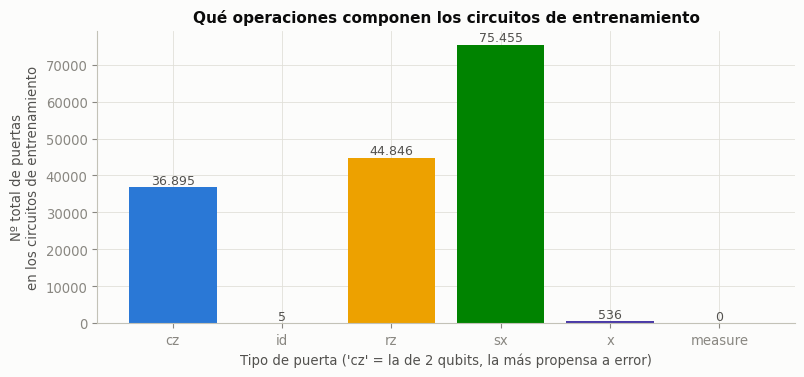

In [12]:
totals = torch.zeros(6)
for f in sorted((Path(PROCESSED_DATA_PATH) / "train").glob("*.pt")):
    totals += torch.load(f, weights_only=False).x[:, :6].sum(dim=0)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(gate_names, totals.numpy(), color=gate_colors)
for i, v in enumerate(totals.numpy()):
    ax.text(i, v, f"{int(v):,}".replace(",", "."), ha="center", va="bottom", fontsize=9, color=INK2)
ax.set_title("Qué operaciones componen los circuitos de entrenamiento")
ax.set_xlabel("Tipo de puerta ('cz' = la de 2 qubits, la más propensa a error)")
ax.set_ylabel("Nº total de puertas\nen los circuitos de entrenamiento")
plt.show()

## Conclusiones (sobre los outputs ejecutados con calibración REAL de IBM)

1. **La calibración real revela lo que la sintética escondía: la enorme heterogeneidad del chip.** Los 156 qubits reales de `ibm_kingston` van de T1=3 µs (un qubit prácticamente muerto) a 422 µs (mediana 240 µs), y el error de lectura va del 0.15% al **32%** según el qubit (mediana 0.88%). La sintética asumía rangos estrechos y "razonables" — la realidad tiene colas extremas. Esto refuerza el diseño del GEM: saber *qué* qubits concretos usa el circuito importa muchísimo.

2. **El dataset es estructuralmente sano** también con datos reales: 178 muestras, distribuciones que suman 1.0, sin leakage entre splits (verificado), y CZ como el 23.4% de las ~158.000 puertas de train.

3. **La señal del target se mantiene**: train std=0.0110 frente al suelo de shot-noise de ±0.0051 — ratio señal/ruido de **2.2×**, con el 57% de las muestras por encima del suelo. Ligeramente menor que con la sintética (2.7×), coherente con que el chip real de Heron es *mejor* de lo que suponíamos (menos error → Δ más pequeños).

4. **⚠️ El límite conocido sigue ahí**: los splits zero-shot (QAOA std=0.0041, QFT std=0.0026) siguen POR DEBAJO del suelo de ruido de medición a 4096 shots. Cualquier métrica zero-shot sobre este mini-dataset sería un espejismo — subir `LABEL_SHOTS` a 16384 en el dataset completo es imprescindible (ROADMAP TAREA 8).

5. **Nota metodológica**: el drift mostrado en la sección 3 sigue siendo el simulado (saltos step-like [SUPOSICIÓN] aplicados SOBRE la calibración real del día 0). El plan vigente es sustituirlo por el histórico REAL de calibraciones diarias (`data/raw/calib_history/`, 29+ días ya archivados) — ROADMAP TAREA 6a.

**Veredicto:** pipeline validado de punta a punta con datos reales de IBM. Listo para TAREA 4 (la comparativa Ridge vs. Random Forest vs. GEM), con las dos mejoras de datos ya identificadas y planificadas (shots ↑ y drift real).